# Results for pm2.5 predictor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
results = pd.read_csv("results/results_log.csv", parse_dates=["timestamp"])
importances = pd.read_csv("results/importance_log.csv", parse_dates=["timestamp"])

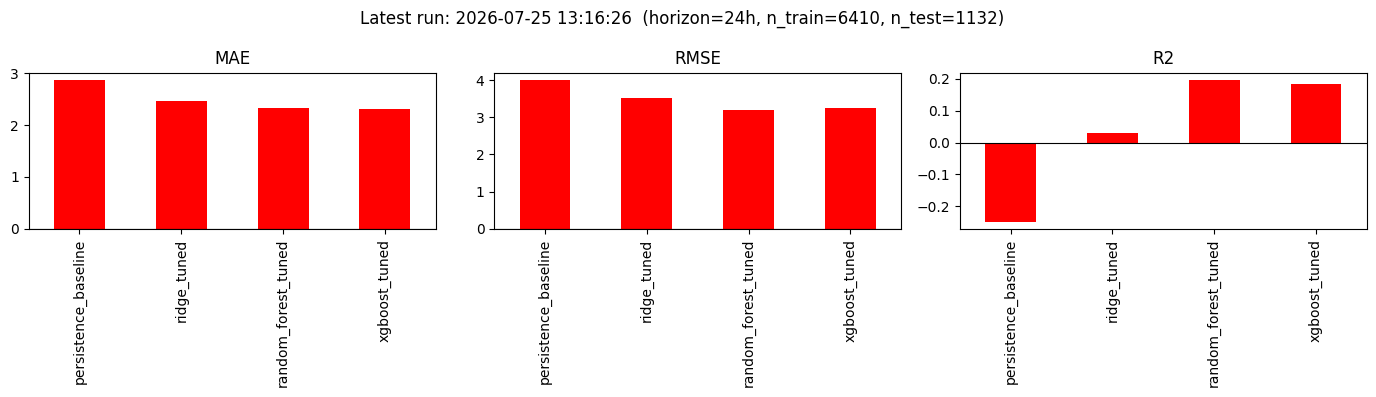

In [7]:
latest_ts = results["timestamp"].max()
latest = results[results["timestamp"] == latest_ts].set_index("model")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    
    latest[metric].plot(kind="bar", ax=ax, color="red")
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.axhline(0, color="black", linewidth=0.8)

fig.suptitle(f"Latest run: {latest_ts}  (horizon={latest['horizon_hours'].iloc[0]}h, "
             f"n_train={latest['n_train'].iloc[0]}, n_test={latest['n_test'].iloc[0]})")
plt.tight_layout()
plt.show()



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, grp in results.groupby("model"):
    grp = grp.sort_values("timestamp")

    axes[0].plot(grp["timestamp"], grp["MAE"], marker="o", label=model_name)
    axes[1].plot(grp["timestamp"], grp["R2"], marker="o", label=model_name)

axes[0].set_title("MAE over time")
axes[0].set_ylabel("MAE (µg/m³)")

axes[1].set_title("R² over time")
axes[1].axhline(0, color="black", linewidth=0.8)

for ax in axes:
    ax.legend()
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>